### HYPER PARAMETERS

In [1]:
max_length = 128  # the maximum length of the sentence, including <sos> and <eos>
min_frequency = 2  # the minimum frequency of a word to be included in the vocabulary
embedding_dim = 512  # the dimension of the embedding vector, known as d_model in the paper
batch_size = 256  # training batch size
head_count = 8  # multihead attention head count
layer_count = 6  # transformer layer count
ff_dim = 2048  # the dimension of the feed forward layer, known as d_ff in the paper
dropout = 0.1  # dropout rate
learning_rate = 2e-4
epochs = 8  # training epochs

Download dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("xseeker0/translation-from-classi"
                                  "cal-chinese-to-english", output_dir="./data")

Read Dataset

In [3]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "weyan_idioms.csv"))
df.head()  # Show first five rows

,zh,en
0,乾统三年，徙封秦国。,"In the third year of the Qingtong Era, he was ..."
1,莽曰监邛。,It was called Jianggongsu in Wang Mang's time.
2,辛未，以复置尚书省诏天下。,"On the tenth day of the first lunar month, an ..."
3,《司马法》广陈三代，曰：古者六尺为步，步百为亩，亩百为夫，夫三为屋，屋三为井。,The Book of Sima's Military Methods extensivel...
4,事平，加特进、右骁卫大将军，弘志右卫上将军兼中尉，守义右领军卫上将军。,"After the incident had ended, Qiu Shiliang was..."


#### Tokenize

|   | English                             |        Chinese        |
|---|:------------------------------------|:---------------------:|
| 1 | Convert to lowercase                |           \           |
| 2 | Add spaces before punctuation marks |           \           |
| 3 | Seperate by space                   | Seperate by character |

In [4]:
import re


def tokenize_en(text: str) -> list[str]:
    basic = r"\S\w*"  # basic case
    hyphen = r"\w+(?:[-']\w+)*"  # handle hyphen: "pre-train"
    point = r"(?:\w+\.)+\w+(?:\.)*"  # handle point: "U.S.A"
    pattern = point + r"|" + hyphen + r"|" + basic
    return re.findall(pattern, text.lower())


def tokenize_zh(text: str) -> list[str]:
    return [char for char in text if not char.isspace()]


# Replace NaN with empty string
df['en'] = df['en'].fillna("")
df['zh'] = df['zh'].fillna("")

# Tokenize
df['en_tokens'] = df['en'].apply(tokenize_en)
df['zh_tokens'] = df['zh'].apply(tokenize_zh)

Tokenize result

In [5]:
df[['zh', 'zh_tokens']].head()

,zh,zh_tokens
0,乾统三年，徙封秦国。,"[乾, 统, 三, 年, ，, 徙, 封, 秦, 国, 。]"
1,莽曰监邛。,"[莽, 曰, 监, 邛, 。]"
2,辛未，以复置尚书省诏天下。,"[辛, 未, ，, 以, 复, 置, 尚, 书, 省, 诏, 天, 下, 。]"
3,《司马法》广陈三代，曰：古者六尺为步，步百为亩，亩百为夫，夫三为屋，屋三为井。,"[《, 司, 马, 法, 》, 广, 陈, 三, 代, ，, 曰, ：, 古, 者, 六, ..."
4,事平，加特进、右骁卫大将军，弘志右卫上将军兼中尉，守义右领军卫上将军。,"[事, 平, ，, 加, 特, 进, 、, 右, 骁, 卫, 大, 将, 军, ，, 弘, ..."


In [6]:
df[['en', 'en_tokens']].head()

,en,en_tokens
0,"In the third year of the Qingtong Era, he was ...","[in, the, third, year, of, the, qingtong, era,..."
1,It was called Jianggongsu in Wang Mang's time.,"[it, was, called, jianggongsu, in, wang, mang'..."
2,"On the tenth day of the first lunar month, an ...","[on, the, tenth, day, of, the, first, lunar, m..."
3,The Book of Sima's Military Methods extensivel...,"[the, book, of, sima's, military, methods, ext..."
4,"After the incident had ended, Qiu Shiliang was...","[after, the, incident, had, ended, ,, qiu, shi..."


Remove too long sentences

In [7]:
original_length = len(df)

df = df[
    (df['en_tokens'].apply(len) <= max_length - 2) &
    (df['zh_tokens'].apply(len) <= max_length - 2)
    ].copy()

print(f"Original sample count: {original_length}")
print(f"Filtered sample count: {len(df)}")
print(f"Discarded excessively long sentences: {original_length - len(df)}")

Original sample count: 1001789
Filtered sample count: 997500
Discarded excessively long sentences: 4289


#### Vocabulary

In [8]:
from collections import Counter

# get all words
words_en = df['en_tokens'].explode().dropna().tolist()
words_zh = df['zh_tokens'].explode().dropna().tolist()

# Special tokens
PAD_TOKEN = "<PAD>"  # padding
UNK_TOKEN = "<UNK>"  # unknown
BOS_TOKEN = "<BOS>"  # beginning of sentence
EOS_TOKEN = "<EOS>"  # end of sentence


class Vocabulary:
    # Use Counter to get vocabulary
    @staticmethod
    def __get_counter(words: list[str], min_freq=1) -> Counter:
        # count raw frequency
        raw_counts = Counter(words)
        # remove low frequency words
        filtered_words = [
            word for word, freq in raw_counts.items()
            if freq >= min_freq and word not in [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]
        ]
        # add special tokens
        return Counter([PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN] + filtered_words)

    def __init__(self, words: list[str], min_freq=1):
        self.__counter = self.__get_counter(words, min_freq)
        self.__str_to_idx = {token: idx for idx, token in enumerate(self.__counter.keys())}
        self.__idx_to_str = {idx: token for token, idx in self.__str_to_idx.items()}
        self.__unk_idx = self.__str_to_idx.get(UNK_TOKEN, 1)

    def __len__(self):
        return len(self.__counter)

    def numericalize(self, sentence: list[str]):
        # if token not in vocabulary, use UNK_TOKEN
        return [self.__str_to_idx.get(token, self.__unk_idx) for token in sentence]

    def denumericalize(self, indices: list[int]):
        return [self.__idx_to_str.get(idx, UNK_TOKEN) for idx in indices]


vocabulary_en = Vocabulary(words_en, min_frequency)
vocabulary_zh = Vocabulary(words_zh, min_frequency)

# calculate PAD idx
PAD_IDX_EN = vocabulary_en.numericalize([PAD_TOKEN])[0]
PAD_IDX_ZH = vocabulary_zh.numericalize([PAD_TOKEN])[0]

Result

In [9]:
pd.concat([df['en'].head(5),
           df['en_tokens'].head(5).apply(vocabulary_en.numericalize)],
          axis=1)

,en,en_tokens
0,"In the third year of the Qingtong Era, he was ...","[4, 5, 6, 7, 8, 5, 9, 10, 11, 12, 13, 14, 15, ..."
1,It was called Jianggongsu in Wang Mang's time.,"[20, 13, 21, 1, 4, 22, 23, 24, 19]"
2,"On the tenth day of the first lunar month, an ...","[25, 5, 26, 27, 8, 5, 28, 29, 30, 11, 31, 32, ..."
3,The Book of Sima's Military Methods extensivel...,"[5, 40, 8, 41, 42, 43, 44, 45, 5, 46, 8, 5, 47..."
4,"After the incident had ended, Qiu Shiliang was...","[71, 5, 72, 73, 74, 11, 75, 76, 13, 77, 15, 78..."


In [10]:
print('Total number of tokens:')
print('zh:', len(vocabulary_zh))
print('en:', len(vocabulary_en))

Total number of tokens:
zh: 10055
en: 88520


In [11]:
max_en_tokens = df['en_tokens'].apply(len).max() + 2
max_zh_tokens = df['zh_tokens'].apply(len).max() + 2

print(f"Longest English sentence (Token): {max_en_tokens}")
print(f"Longest Chinese sentence (Token): {max_zh_tokens}")

Longest English sentence (Token): 128
Longest Chinese sentence (Token): 128


#### Dataset

In [12]:
from torch.utils.data import Dataset
import torch


class TranslationDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, vocab_en: Vocabulary, vocab_zh: Vocabulary):
        self.dataframe = dataframe
        self.vocab_en = vocab_en
        self.vocab_zh = vocab_zh

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        # Get sentence and add special tokens
        en_sentence = [BOS_TOKEN] + self.dataframe.iloc[index]['en_tokens'] + [EOS_TOKEN]
        zh_sentence = [BOS_TOKEN] + self.dataframe.iloc[index]['zh_tokens'] + [EOS_TOKEN]

        # Convert to indices
        en_sentence = self.vocab_en.numericalize(en_sentence)
        zh_sentence = self.vocab_zh.numericalize(zh_sentence)

        # Convert to tensors
        return torch.tensor(en_sentence), torch.tensor(zh_sentence)

#### Position encoding

According to the [**paper**](https://arxiv.org/pdf/1706.03762), the position encoding is defined as follows:

$$
\begin{aligned}
PE_{(pos,2i)} = sin(pos / 10000^{2i/ d_{model}}) \\
PE_{(pos,2i+1)} = cos(pos / 10000^{2i/ d_{model}})
\end{aligned}
$$

where $pos$ is the position of the token in the sequence and $i$ is the index along the embedding dimension ($d_{model}$)

Here we use NumPy to generate the position encoding matrix and convert it to a Torch tensor

In [13]:
import numpy as np


def get_position_encoding_matrix(max_len, d_model):
    pe = np.zeros((max_len, d_model))
    # pos
    position = np.arange(0, max_len)[:, np.newaxis]  # [max_len, 1]

    # 10000^(2i/d_model)
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    # calculate by broadcasting
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)

    return pe

Result (heat map)

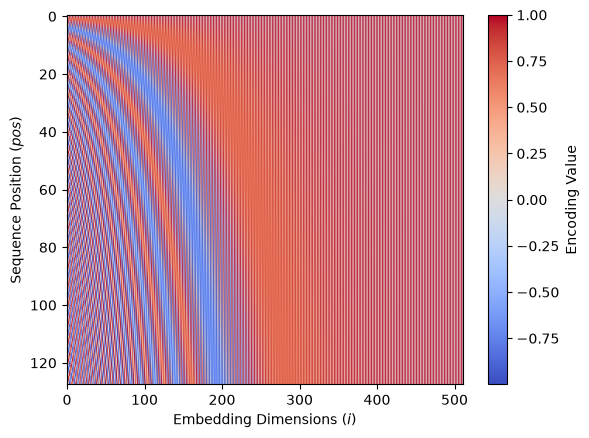

In [14]:
import matplotlib.pyplot as plt

pe_matrix = get_position_encoding_matrix(max_length, embedding_dim)

plt.imshow(pe_matrix, cmap='coolwarm', aspect='auto')

plt.colorbar(label='Encoding Value')
plt.xlabel("Embedding Dimensions ($i$)")
plt.ylabel("Sequence Position ($pos$)")

plt.show()

#### Transformer Model

<img src="./imgs/ModalNet-21.png" width="35%">

Here we need to implement the following components:
- Embedding block (Embedding + Position Encoding)

And these blocks with residual connection and layer normalization:
- Multi-head Attention (Mask is optional)
- Feed Forward Network

Embedding block (Input Embedding + Position Encoding)

In [15]:
from torch import nn
import math


class Embedding(nn.Module):
    def __init__(self,
                 vocab_size: int,
                 embedding_dim: int,
                 max_len: int
                 ):
        super().__init__()
        self.embedding_dim = embedding_dim
        # word embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # get position encoding matrix and buffer it
        pe = torch.tensor(get_position_encoding_matrix(max_len, embedding_dim), dtype=torch.float32).unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, sentence: torch.Tensor):
        sentence = self.embedding(sentence) * math.sqrt(self.embedding_dim)
        sentence = sentence + self.pe[:, :sentence.shape[1]]
        return sentence

Multi-head attention

<div style="display: flex; justify-content: center; align-items: center; gap: 100px;">
  <img src="./imgs/ModalNet-19.png" style="height: 300px;">
  <img src="./imgs/ModalNet-20.png" style="height: 300px;">
</div>


In [16]:
class MultiHeadAttention(nn.Module):
    def __init__(self,
                 embedding_dim: int,
                 num_heads: int,
                 dropout: float = 0.1
                 ):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.head_dim = embedding_dim // num_heads

        assert (
                self.head_dim * num_heads == embedding_dim
        ), "embedding_dim must be divisible by num_heads"

        self.q_linear = nn.Linear(embedding_dim, embedding_dim)
        self.k_linear = nn.Linear(embedding_dim, embedding_dim)
        self.v_linear = nn.Linear(embedding_dim, embedding_dim)
        self.out_linear = nn.Linear(embedding_dim, embedding_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self,
                q: torch.Tensor,
                k: torch.Tensor,
                v: torch.Tensor,
                mask: torch.Tensor
                ):
        __batch_size = q.size(0)

        # linear projections
        q = self.q_linear(q).view(__batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_linear(k).view(__batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_linear(v).view(__batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

        # scaled dot-product attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        output = torch.matmul(attn_weights, v)
        output = output.transpose(1, 2).contiguous().view(__batch_size, -1, self.embedding_dim)
        return self.out_linear(output)

Feed Forward Network

In [17]:
class FeedForward(nn.Module):
    def __init__(self,
                 embedding_dim: int,
                 ff_dim: int,
                 dropout: float = 0.1
                 ):
        super().__init__()
        self.linear1 = nn.Linear(embedding_dim, ff_dim)
        self.linear2 = nn.Linear(ff_dim, embedding_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        x = self.dropout(torch.relu(self.linear1(x)))
        return self.linear2(x)

Encoder Layer (Multi-head Attention + Feed Forward Network)

In [18]:
import torch.nn as nn


class EncoderLayer(nn.Module):
    def __init__(self,
                 embedding_dim: int,
                 heads: int,
                 ff_dim: int,
                 dropout: float
                 ):
        super().__init__()
        self.self_attention = MultiHeadAttention(embedding_dim, heads, dropout)
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.feed_forward = FeedForward(embedding_dim, ff_dim, dropout)
        self.norm2 = nn.LayerNorm(embedding_dim)

    def forward(self,
                input: torch.Tensor,
                mask: torch.Tensor
                ):
        # Self-attention
        attn_output = self.self_attention(input, input, input, mask)
        # residual connection
        attn_output = self.norm1(attn_output + input)

        # Feed forward
        ff_output = self.feed_forward(attn_output)
        # residual connection
        output = self.norm2(ff_output + attn_output)

        return output

Decoder Layer (Masked Multi-head Attention + Cross Attention + Feed Forward Network)

In [19]:
class DecoderLayer(nn.Module):
    def __init__(self,
                 embedding_dim: int,
                 heads: int,
                 ff_dim: int,
                 dropout: float
                 ):
        super().__init__()
        self.masked_attention = MultiHeadAttention(embedding_dim, heads, dropout)
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.cross_attention = MultiHeadAttention(embedding_dim, heads, dropout)
        self.norm2 = nn.LayerNorm(embedding_dim)
        self.feed_forward = FeedForward(embedding_dim, ff_dim, dropout)
        self.norm3 = nn.LayerNorm(embedding_dim)

    def forward(self,
                input: torch.Tensor,
                encoder_output: torch.Tensor,
                mask: torch.Tensor,
                cross_mask: torch.Tensor
                ):
        # Masked multi-head attention
        self_attention = self.masked_attention(input, input, input, mask=mask)
        # residual connection
        self_attention = self.norm1(self_attention + input)

        # Cross attention(use K,V from encoder)
        cross_attention = self.cross_attention(self_attention, encoder_output, encoder_output, mask=cross_mask)
        # residual connection
        cross_attention = self.norm2(cross_attention + self_attention)

        # Feed forward network
        feed_forward = self.feed_forward(cross_attention)
        # residual connection
        output = self.norm3(feed_forward + cross_attention)

        return output

Transformer

In [20]:
class Transformer(nn.Module):
    def __init__(self,
                 src_vocab_size: int,
                 tgt_vocab_size: int,
                 embedding_dim: int,
                 head_count: int,
                 layer_count: int,
                 ff_dim: int,
                 dropout: float,
                 max_len: int
                 ):
        super().__init__()
        # embedding(with positional encoding)
        self.src_embedding = Embedding(src_vocab_size, embedding_dim, max_len)
        self.tgt_embedding = Embedding(tgt_vocab_size, embedding_dim, max_len)

        # encoder & decoder
        self.encoder = nn.ModuleList(
            [EncoderLayer(embedding_dim, head_count, ff_dim, dropout) for _ in range(layer_count)]
        )
        self.decoder = nn.ModuleList(
            [DecoderLayer(embedding_dim, head_count, ff_dim, dropout) for _ in range(layer_count)]
        )

        # final linear layer
        self.feed_forward = nn.Linear(embedding_dim, tgt_vocab_size)

    def forward(self,
                src: torch.Tensor,
                tgt: torch.Tensor,
                src_pad_idx: int,
                tgt_pad_idx: int,
                ):
        # padding mask
        src_mask = (src != src_pad_idx).unsqueeze(1).unsqueeze(2)
        tgt_pad_mask = (tgt != tgt_pad_idx).unsqueeze(1).unsqueeze(2)

        # target causal mask
        tgt_len = tgt.size(1)
        tgt_causal_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=tgt.device)).bool()
        tgt_mask = tgt_pad_mask & tgt_causal_mask

        # embedding
        src = self.src_embedding(src)
        tgt = self.tgt_embedding(tgt)

        # encoder
        for layer in self.encoder:
            src = layer(src, mask=src_mask)

        # decoder
        for layer in self.decoder:
            tgt = layer(tgt, src, mask=tgt_mask, cross_mask=src_mask)

        # final linear layer
        output = self.feed_forward(tgt)
        return output

    # Generate method for inference
    def generate(self,
                 src: torch.Tensor,
                 src_pad_idx: int,
                 max_len: int,
                 start_token_idx: int,
                 end_token_idx: int,
                 tgt_pad_idx: int
                 ):
        self.eval()
        with torch.no_grad():
            # Encode source sentence
            src_mask = (src != src_pad_idx).unsqueeze(1).unsqueeze(2)
            src_embedded = self.src_embedding(src)
            for layer in self.encoder:
                src_embedded = layer(src_embedded, mask=src_mask)

            # Initialize target sequence with start token
            tgt_indices = [start_token_idx]
            for _ in range(max_len):
                tgt_tensor = torch.tensor(tgt_indices, device=src.device).unsqueeze(0)
                tgt_mask = (tgt_tensor != tgt_pad_idx).unsqueeze(1).unsqueeze(2)
                tgt_causal_mask = torch.tril(
                    torch.ones((tgt_tensor.size(1), tgt_tensor.size(1)), device=src.device)).bool()
                combined_mask = tgt_mask & tgt_causal_mask

                # Decode step
                tgt_embedded = self.tgt_embedding(tgt_tensor)
                for layer in self.decoder:
                    tgt_embedded = layer(tgt_embedded, src_embedded, mask=combined_mask, cross_mask=src_mask)

                output_logits = self.feed_forward(tgt_embedded[:, -1, :])
                next_token_idx = output_logits.argmax(dim=-1).item()
                tgt_indices.append(next_token_idx)

                if next_token_idx == end_token_idx:
                    break

        return tgt_indices

In [21]:
# get gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current using device:", device)

Current using device: cuda


#### Result

build the translator

In [22]:
# load model from save
saved_model = (Transformer(
    len(vocabulary_en),
    len(vocabulary_zh),
    embedding_dim,
    head_count,
    layer_count,
    ff_dim,
    dropout,
    max_length,
))
saved_model.load_state_dict(torch.load("model.pth", map_location=device))
saved_model = saved_model.to(device)
saved_model.eval()


class Translator:
    def __init__(self, model, vocab_src, vocab_tgt, max_len=max_length):
        self.model = model.eval()
        self.vocab_src = vocab_src
        self.vocab_tgt = vocab_tgt
        self.max_len = max_len

    def translate(self, sentence: str) -> str:
        tokens = [BOS_TOKEN] + tokenize_en(sentence) + [EOS_TOKEN]
        src_indices = torch.tensor(self.vocab_src.numericalize(tokens)).unsqueeze(0).to(device)

        with torch.no_grad():
            tgt_indices = self.model.generate(
                src=src_indices,
                src_pad_idx=PAD_IDX_EN,
                tgt_pad_idx=PAD_IDX_ZH,
                max_len=self.max_len,
                start_token_idx=self.vocab_tgt.numericalize([BOS_TOKEN])[0],
                end_token_idx=self.vocab_tgt.numericalize([EOS_TOKEN])[0]
            )

        # remove BOS and EOS
        translated_tokens = self.vocab_tgt.denumericalize(tgt_indices[1:-1])
        return "".join(translated_tokens)


translator = Translator(saved_model, vocabulary_en, vocabulary_zh)

Test translation

In [28]:
print(translator.translate("Man! What can I say?"))
print(translator.translate("There was no snow in winter."))
print(translator.translate("I will die for my country, what else is there to say?"))
print(translator.translate("Attention is all you need."))
print(translator.translate("I love you."))
print(translator.translate("Don’t compare your life with others. There’s no comparison between the sun and the moon."))

人之言，吾何言焉！
冬无雪。
吾死国家，何辞之有！
诸君宜留意。
吾爱子。
不如人，日月之间，无相比也。


#### Reference
[Attention Is All You Need](https://arxiv.org/pdf/1706.03762.pdf)